# Will it rain tomorrow? A deployable rain forecast for Australian weather stations

**32513 / 31005 Advanced Data Analytics Algorithms, Machine Learning – Assessment 2 (Option 2)**
**Student:** Ngoc Dang Nguyen (26059877)

This notebook is the full implementation of my A2 project. It is self-contained: it installs what it needs,
downloads the data from the original public sources, prepares the data, trains the models and produces every
number and figure used in my journal.

**The task in one sentence.** At 3:30 pm on day *t*, a weather station has its morning (9 am) and afternoon (3 pm)
readings. The system must output the probability that **more than 1 mm of rain falls during the next rain day**
(9 am on day *t+1* to 9 am on day *t+2*).

**Why this is not the usual Kaggle task.** The popular "Rain in Australia" target (`RainTomorrow`) looks like the same
question, but because of how the Bureau of Meteorology (BOM) records rainfall, it actually covers
9 am *today* to 9 am *tomorrow*. Several input columns are measured inside that window. Section 3 shows this
and measures how much it inflates the results.

**Structure**
1. Setup
2. Data: download, check and describe
3. Feasibility check 1: leakage and the timing of every feature
4. Task definition (inputs and outputs for training and deployment)
5. Preprocessing
6. Validation design (time-based split)
7. Baselines (the "incumbent" rules)
8. Models: Logistic Regression, LightGBM, MLP, GRU and Transformer (the last three are deep learning; GRU and Transformer use a 7-day history)
9. From probability to decision: loss vs. task objective, threshold by cost
10. Reliability: random vs. time split, year-by-year evaluation, unseen cities, per-city errors, sensitivity
11. Deployment test on real 2026 data downloaded from BOM (data the models have never seen)
12. Cost of training and prediction
13. Summary of results

Runtime on Google Colab (CPU): about 10–15 minutes in total.

## 1. Setup
All libraries below are pre-installed on Google Colab. The `pip` line only makes sure LightGBM is present when the
notebook is run somewhere else. I fix all random seeds so that the numbers in the journal can be reproduced.

In [1]:
import sys, subprocess
try:
    import lightgbm
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "lightgbm"], check=True)

import os, io, json, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import lightgbm as lgb
import torch
import torch.nn as nn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (log_loss, brier_score_loss, roc_auc_score, average_precision_score,
                             precision_score, recall_score, f1_score, accuracy_score,
                             confusion_matrix, precision_recall_curve)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import GroupKFold

warnings.filterwarnings("ignore")
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
set_seed()
# On macOS, LightGBM and PyTorch load two different OpenMP libraries. When PyTorch then uses several
# threads, training can freeze (I met this problem, see the implementation log). One thread avoids it.
# On Colab (Linux) this conflict does not happen, so all CPU threads are used there.
torch.set_num_threads(1 if sys.platform == "darwin" else max(1, os.cpu_count() or 1))
DEVICE = "cpu"   # CPU keeps the deep learning results reproducible and is fast enough here

os.makedirs("data", exist_ok=True); os.makedirs("figures", exist_ok=True); os.makedirs("results", exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "font.size": 10, "axes.grid": True, "grid.alpha": 0.3})
RESULTS = {}   # every number reported in the journal is stored here and saved to results/results.json

print("python", sys.version.split()[0], "| pandas", pd.__version__, "| numpy", np.__version__,
      "| lightgbm", lgb.__version__, "| torch", torch.__version__)

python 3.11.8 | pandas 2.2.2 | numpy 2.4.3 | lightgbm 4.6.0 | torch 2.11.0


## 2. Data
**Main source.** `weatherAUS.csv` from the `rattle` project (Togaware). This is the original source of the Kaggle
dataset "Rain in Australia", but it is longer: it runs from November 2007 to January 2026, while the Kaggle copy stops
in 2017. The observations come from the BOM *Daily Weather Observations* (© Commonwealth of Australia, Bureau of Meteorology).

The file is updated from time to time, so I **cut the data at 30 January 2026**. This makes the results reproducible even if new rows are added later.

**Second source (Section 11).** BOM monthly CSV files for Sydney, Melbourne, Brisbane, Perth and Canberra,
January–September 2026. They are downloaded directly from the BOM website.

If a download fails (for example, a website blocks the request), the notebook falls back to a snapshot copy.
Set `SNAPSHOT_BASE` to the `data/` folder of the project GitHub repository.

In [2]:
MAIN_URL = "https://rattle.togaware.com/weatherAUS.csv"
SNAPSHOT_BASE = "https://raw.githubusercontent.com/nndang27/rain-forecast-au/main/data/"   # fallback copy
CUTOFF = "2026-01-30"
HEADERS = {"User-Agent": "Mozilla/5.0 (UTS student project; educational use)"}

def download(url, path, fallback=None):
    """Download a file once; use the snapshot copy if the original source is not reachable."""
    if os.path.exists(path):
        return path
    for u in [url, fallback]:
        if u is None:
            continue
        try:
            r = requests.get(u, headers=HEADERS, timeout=60)
            r.raise_for_status()
            open(path, "wb").write(r.content)
            print("downloaded", u)
            return path
        except Exception as e:
            print("failed", u, "->", e)
    raise RuntimeError(f"could not download {url}")

download(MAIN_URL, "data/weatherAUS.csv", SNAPSHOT_BASE + "weatherAUS.csv")
raw = pd.read_csv("data/weatherAUS.csv", parse_dates=["Date"])
raw = raw[raw["Date"] <= CUTOFF].copy()
print(raw.shape)
print("dates:", raw.Date.min().date(), "to", raw.Date.max().date(), "| locations:", raw.Location.nunique())
raw.head(3)

(275410, 24)
dates: 2007-11-01 to 2026-01-30 | locations: 49


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No


A short data card. I only show what is used later in the design (no general EDA):
the class balance (it decides the metrics), the missing values (they decide the preprocessing) and
the number of rows per year (it shows a gap in 2016 that affects the time split).

In [3]:
rows_per_year = raw.groupby(raw.Date.dt.year).size()
missing = (raw.isna().mean() * 100).round(1).sort_values(ascending=False)
target_share = raw.RainTomorrow.value_counts(normalize=True, dropna=False).round(3)
print("Rows per year:\n", rows_per_year.to_string())
print("\nMissing values (%), top 8:\n", missing.head(8).to_string())
print("\nRainTomorrow share:\n", target_share.to_string())
RESULTS["data"] = {"rows": int(len(raw)), "locations": int(raw.Location.nunique()),
                   "first_date": str(raw.Date.min().date()), "last_date": str(raw.Date.max().date()),
                   "rows_2016": int(rows_per_year.get(2016, 0)),
                   "missing_pct": missing.head(8).to_dict(),
                   "raintomorrow_yes": float(target_share.get("Yes", np.nan))}

Rows per year:
 Date
2007       61
2008     2270
2009    16789
2010    16782
2011    15407
2012    15409
2013    16415
2014    17885
2015    17885
2016     1265
2017    14994
2018    17821
2019    17884
2020    17780
2021    17181
2022    17094
2023    17148
2024    17170
2025    16790
2026     1380

Missing values (%), top 8:
 Sunshine       62.1
Evaporation    58.1
Cloud3pm       48.2
Cloud9am       45.9
Pressure9am    11.0
Pressure3pm    11.0
WindDir9am      7.8
WindGustDir     7.4

RainTomorrow share:
 RainTomorrow
No     0.757
Yes    0.214
NaN    0.029


**Missing values are not random.** Sunshine, Evaporation and Cloud are missing because many stations do not have
those instruments. So "missing" carries information about the station. I keep this information with missing-value flags
instead of hiding it (Section 5).

In [4]:
miss_by_loc = raw.groupby("Location")[["Sunshine", "Evaporation", "Cloud3pm"]].apply(lambda d: d.isna().mean())
print("Stations where Sunshine is missing on more than 95% of days:", int((miss_by_loc.Sunshine > 0.95).sum()), "of", len(miss_by_loc))
print("Stations where Sunshine is missing on less than 10% of days:", int((miss_by_loc.Sunshine < 0.10).sum()))
RESULTS["data"]["stations_no_sunshine"] = int((miss_by_loc.Sunshine > 0.95).sum())

Stations where Sunshine is missing on more than 95% of days: 19 of 49
Stations where Sunshine is missing on less than 10% of days: 10


## 3. Feasibility check 1: leakage and the timing of every feature

A feature can only be used if its value is **known at the moment the prediction is made**.
I check this in two steps.

**Step 1: an obvious leak.** The rattle file has a column `RISK_MM`. The check below shows that it is exactly the
rainfall recorded on the next day, and that `RainTomorrow` is simply `RISK_MM > 1`. It is the answer, not a feature.

In [5]:
raw = raw.sort_values(["Location", "Date"]).reset_index(drop=True)
next_day_rain = raw.groupby("Location")["Rainfall"].shift(-1)
consecutive = raw.groupby("Location")["Date"].diff(-1).abs() == pd.Timedelta(days=1)
m = raw.RISK_MM.notna() & next_day_rain.notna() & consecutive
same_as_next = float(np.isclose(raw.RISK_MM[m], next_day_rain[m]).mean())
m2 = raw.RISK_MM.notna() & raw.RainTomorrow.notna()
target_rule = float(((raw.RISK_MM[m2] > 1) == (raw.RainTomorrow[m2] == "Yes")).mean())
print(f"RISK_MM equals next day's Rainfall on {same_as_next:.1%} of days")
print(f"RainTomorrow == (RISK_MM > 1) on {target_rule:.1%} of days")
RESULTS["leak"] = {"riskmm_equals_next_rain": same_as_next, "target_equals_riskmm_gt1": target_rule}

RISK_MM equals next day's Rainfall on 100.0% of days
RainTomorrow == (RISK_MM > 1) on 100.0% of days


**Step 2: a hidden timing problem.** The BOM notes (*Notes to accompany Daily Weather Observations*) define the
observation window of each column. For the row with date *t*:

| Column | Observation window | Known at |
|---|---|---|
| Rainfall, MinTemp, Evaporation | 24 h **to** 9 am on day *t* | 9 am day *t* |
| 9 am readings (temp, humidity, cloud, wind, pressure) | at 9 am day *t* | 9 am day *t* |
| 3 pm readings | at 3 pm day *t* | 3 pm day *t* |
| Sunshine, WindGustDir, WindGustSpeed | 24 h to **midnight** of day *t* | midnight day *t* |
| MaxTemp | 24 h **from** 9 am day *t* | 9 am day *t+1* |

`RainTomorrow` of row *t* is the rainfall of row *t+1*, so it measures rain from **9 am day *t* to 9 am day *t+1***.
This means the usual Kaggle set-up predicts a window that has already started. The 3 pm readings are taken six hours
into it, and MaxTemp, Sunshine and WindGust are only complete **after** part of it has passed. The figure shows this.

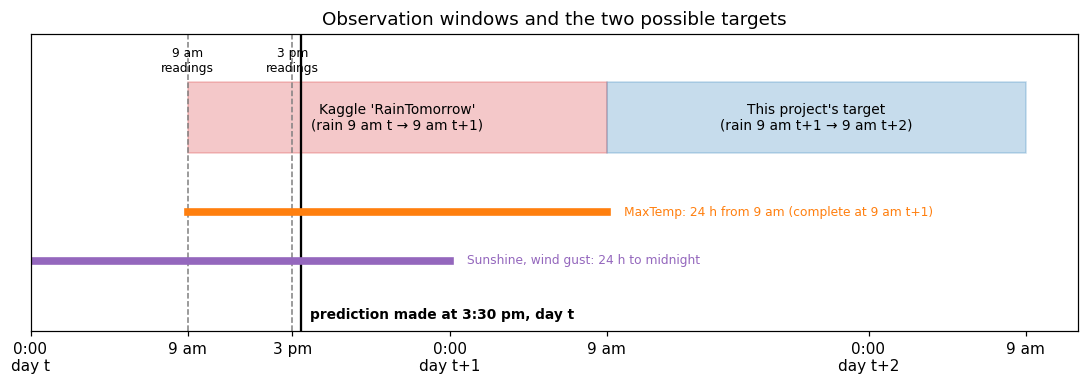

In [6]:
fig, ax = plt.subplots(figsize=(10, 3.6))
day = lambda d, h: d * 24 + h            # hours from midnight of day t
ax.axvspan(day(0, 9), day(1, 9), ymin=0.60, ymax=0.84, color="tab:red", alpha=0.25)
ax.text(day(0, 21), 0.79, "Kaggle 'RainTomorrow'\n(rain 9 am t → 9 am t+1)", ha="center", va="center", fontsize=9)
ax.axvspan(day(1, 9), day(2, 9), ymin=0.60, ymax=0.84, color="tab:blue", alpha=0.25)
ax.text(day(1, 21), 0.79, "This project's target\n(rain 9 am t+1 → 9 am t+2)", ha="center", va="center", fontsize=9)
for h, lab in [(day(0, 9), "9 am\nreadings"), (day(0, 15), "3 pm\nreadings")]:
    ax.axvline(h, color="grey", lw=1, ls="--")
    ax.text(h, 1.0, lab, ha="center", va="center", fontsize=8)
ax.axvline(day(0, 15.5), color="k", lw=1.5)
ax.text(day(0, 16), 0.06, "prediction made at 3:30 pm, day t", ha="left", va="center", fontsize=9, fontweight="bold")
ax.plot([day(0, 9), day(1, 9)], [0.44, 0.44], color="tab:orange", lw=5)
ax.text(day(1, 10), 0.44, "MaxTemp: 24 h from 9 am (complete at 9 am t+1)", fontsize=8, color="tab:orange", va="center")
ax.plot([day(0, 0), day(1, 0)], [0.26, 0.26], color="tab:purple", lw=5)
ax.text(day(1, 1), 0.26, "Sunshine, wind gust: 24 h to midnight", fontsize=8, color="tab:purple", va="center")
ax.set_xlim(day(0, 0), day(2, 12)); ax.set_ylim(0, 1.1); ax.set_yticks([])
ax.set_xticks([day(0, 0), day(0, 9), day(0, 15), day(1, 0), day(1, 9), day(2, 0), day(2, 9)])
ax.set_xticklabels(["0:00\nday t", "9 am", "3 pm", "0:00\nday t+1", "9 am", "0:00\nday t+2", "9 am"])
ax.set_title("Observation windows and the two possible targets"); ax.grid(False)
plt.tight_layout(); plt.savefig("figures/fig1_timeline.png"); plt.show()

## 4. Task definition

**Prediction time:** 3:30 pm on day *t*, after the 3 pm reading.

**Output (deployment):** a probability *p* in [0, 1] that the rainfall recorded at 9 am on day *t+2* is more than 1 mm.
A decision rule (Section 9) turns *p* into "Rain" or "No rain".

**Input (deployment), one vector per station per day.** Only values that are known at 3:30 pm:
- today's readings to 9 am: `MinTemp`, `Rainfall`, `Evaporation`
- the 9 am and 3 pm readings: temperature, humidity, cloud, wind speed, wind direction, pressure (12 values)
- yesterday's full-day values instead of today's: `MaxTemp_lag1`, `Sunshine_lag1`, `WindGustSpeed_lag1`, `WindGustDir_lag1`
- three simple changes during the day: pressure, humidity and temperature (3 pm minus 9 am)
- the station (`Location`, one of 49) and the month (encoded as a point on a circle)
- four flags that say whether Sunshine, Evaporation, Cloud 9 am and Cloud 3 pm are missing

**Training data:** pairs (input vector for day *t*, label = 1 if Rainfall of day *t+2* > 1 mm, else 0).
For the GRU and Transformer models, the input is the sequence of the same vectors for days *t−6 … t*.

For comparison I also build the **"standard" Kaggle task**: all columns of day *t* as they are, and the label `RainTomorrow`.

In [7]:
NUM_BASE = ["MinTemp", "Rainfall", "Evaporation", "Temp9am", "Humidity9am", "Cloud9am", "WindSpeed9am", "Pressure9am",
            "Temp3pm", "Humidity3pm", "Cloud3pm", "WindSpeed3pm", "Pressure3pm"]
DIRS = ["N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE", "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW"]
DIR_ANGLE = {d: 2 * np.pi * i / 16 for i, d in enumerate(DIRS)}

def complete_calendar(df):
    """One row per station per calendar day, so that 'shift' always means 'one day'."""
    out = []
    for loc, g in df.groupby("Location"):
        g = g.set_index("Date").reindex(pd.date_range(g.Date.min(), g.Date.max(), freq="D"))
        g["Location"] = loc
        g["row_missing"] = g["MinTemp"].isna() & g["Rainfall"].isna() & g["Humidity3pm"].isna()
        out.append(g.rename_axis("Date").reset_index())
    return pd.concat(out, ignore_index=True)

def add_features(df):
    """Build both tasks' labels and the time-safe feature set."""
    df = df.sort_values(["Location", "Date"]).reset_index(drop=True)
    g = df.groupby("Location")
    df["rain_t1"] = g["Rainfall"].shift(-1)             # rain 9am t -> 9am t+1 (Kaggle window)
    df["rain_t2"] = g["Rainfall"].shift(-2)             # rain 9am t+1 -> 9am t+2 (our window)
    df["y_honest"] = np.where(df.rain_t2.notna(), (df.rain_t2 > 1).astype(float), np.nan)
    df["y_standard"] = np.where(df.rain_t1.notna(), (df.rain_t1 > 1).astype(float), np.nan)
    for c in ["MaxTemp", "Sunshine", "WindGustSpeed", "WindGustDir"]:
        df[c + "_lag1"] = g[c].shift(1)                  # yesterday's value is complete at 3:30 pm today
    df["PressureChange"] = df.Pressure3pm - df.Pressure9am
    df["HumidityChange"] = df.Humidity3pm - df.Humidity9am
    df["TempChange"] = df.Temp3pm - df.Temp9am
    month = df.Date.dt.month
    df["month_sin"], df["month_cos"] = np.sin(2 * np.pi * month / 12), np.cos(2 * np.pi * month / 12)
    return df

def dir_to_xy(s):
    ang = s.map(DIR_ANGLE)
    return np.sin(ang).fillna(0.0), np.cos(ang).fillna(0.0)   # missing / calm -> (0, 0), the centre of the circle

def feature_frame(df, task="honest"):
    """Return the raw (not yet imputed) numeric feature table for one task."""
    X = pd.DataFrame(index=df.index)
    if task == "honest":
        num = NUM_BASE + ["MaxTemp_lag1", "Sunshine_lag1", "WindGustSpeed_lag1",
                          "PressureChange", "HumidityChange", "TempChange"]
        dirs = ["WindDir9am", "WindDir3pm", "WindGustDir_lag1"]
        flags = {"Sunshine_lag1": "miss_sunshine", "Evaporation": "miss_evap",
                 "Cloud9am": "miss_cloud9", "Cloud3pm": "miss_cloud3"}
    else:  # the standard Kaggle feature set: every column of day t
        num = NUM_BASE + ["MaxTemp", "Sunshine", "WindGustSpeed", "PressureChange", "HumidityChange", "TempChange"]
        dirs = ["WindDir9am", "WindDir3pm", "WindGustDir"]
        flags = {"Sunshine": "miss_sunshine", "Evaporation": "miss_evap", "Cloud9am": "miss_cloud9", "Cloud3pm": "miss_cloud3"}
    for c in num:
        X[c] = pd.to_numeric(df[c], errors="coerce")
    for c in dirs:
        X[c + "_sin"], X[c + "_cos"] = dir_to_xy(df[c])
    for c, f in flags.items():
        X[f] = df[c].isna().astype(float)
    X["month_sin"], X["month_cos"] = df.month_sin, df.month_cos
    return X

full = add_features(complete_calendar(raw.drop(columns=["RainToday", "RainTomorrow"])))
full = full[~full.row_missing].reset_index(drop=True)
# sanity check: our y_standard must equal the original RainTomorrow column
chk = raw.merge(full[["Location", "Date", "y_standard"]], on=["Location", "Date"])
chk = chk[chk.RainTomorrow.notna() & chk.y_standard.notna()]
print("y_standard matches RainTomorrow:", f"{((chk.RainTomorrow == 'Yes') == (chk.y_standard == 1)).mean():.2%}")
print("Rows with the honest label:", int(full.y_honest.notna().sum()), "| positive share:", round(full.y_honest.mean(), 3))
RESULTS["data"]["rows_honest"] = int(full.y_honest.notna().sum())
RESULTS["data"]["positive_share_honest"] = float(full.y_honest.mean())

y_standard matches RainTomorrow: 100.00%
Rows with the honest label: 266609 | positive share: 0.22


## 5. Preprocessing

All statistics (medians, means, standard deviations, station list) are learned **from the training years only** and then
applied to validation, test and 2026 data. Learning them from all years would leak future information.

- **Missing numbers:** filled with the training median. The missing flags keep the information that the value was missing.
- **Wind direction:** a compass point is an angle, so N and NNW are neighbours. I map it to (sin, cos) instead of 16 unrelated categories.
- **Month:** also a circle (December is next to January), so (sin, cos).
- **Scaling:** Logistic Regression and the neural networks get standardised inputs (mean 0, std 1). LightGBM does not need it.
- **Station:** one-hot for Logistic Regression, a category for LightGBM, a learned 8-number embedding for the neural networks.

In [8]:
class Prep:
    """Fit on training rows only; transform any rows the same way."""
    def fit(self, X, loc):
        self.cols = list(X.columns)
        self.median = X.median()
        Xf = X.fillna(self.median)
        self.mean, self.std = Xf.mean(), Xf.std().replace(0, 1)
        self.locs = sorted(loc.unique())
        self.loc_index = {l: i for i, l in enumerate(self.locs)}
        return self
    def filled(self, X):
        return X[self.cols].fillna(self.median)
    def scaled(self, X):
        return ((self.filled(X) - self.mean) / self.std).values.astype(np.float32)
    def loc_ids(self, loc):
        return loc.map(self.loc_index).fillna(len(self.locs)).astype(int).values   # unknown station -> extra id
    def onehot(self, loc):
        ids = self.loc_ids(loc); oh = np.zeros((len(ids), len(self.locs) + 1), dtype=np.float32)
        oh[np.arange(len(ids)), ids] = 1.0
        return oh

## 6. Validation design

The model will be used to predict the **future**, so the split follows time. I also avoid a random split on purpose,
because days that are next to each other in time have very similar weather (Section 10.1 measures the effect).

| Part | Prediction days | Used for |
|---|---|---|
| Train | 2008 – 2019 | fitting the models |
| Validation | 2020 – 2021 | early stopping, choosing the threshold, comparing settings |
| Test | 2022 – 28 Jan 2026 | final numbers, used **once** |
| Deployment test | Feb – Aug 2026, 5 cities, new BOM files | Section 11 |

The 2016 gap (only a few stations recorded) sits inside the training period, so it does not break the split.

In [9]:
def split_of(dates):
    y = dates.dt.year
    return np.select([y <= 2019, y <= 2021], ["train", "val"], "test")

full["split"] = split_of(full.Date)
data = full[full.y_honest.notna()].copy()
data_std = full[full.y_standard.notna()].copy()
counts = data.groupby("split").agg(rows=("y_honest", "size"), rain_share=("y_honest", "mean")).loc[["train", "val", "test"]]
print(counts.round(3))
RESULTS["split_counts"] = counts.round(4).to_dict()

Xh = feature_frame(data, "honest")
prep = Prep().fit(Xh[data.split == "train"], data.Location[data.split == "train"])
idx = {s: np.where(data.split.values == s)[0] for s in ["train", "val", "test"]}
y = data.y_honest.values.astype(int)
print("number of input features:", len(prep.cols), "+ station")

         rows  rain_share
split                    
train  166216       0.214
val     33182       0.237
test    67211       0.227
number of input features: 31 + station


## Evaluation tools

The **training loss** of every model is the binary cross-entropy (log-loss):
$L = -[y\log p + (1-y)\log(1-p)]$. From Module 3, minimising it makes *p* close to the true probability
of rain (it minimises the KL divergence between the true and the predicted distributions).

The **task objective** is different. A user needs a yes/no decision, and a missed rain day costs more than a false alarm.
I report:
- **log-loss** (the same quantity the models are trained on) and the **Brier score** (probability quality),
- **PR-AUC** (average precision), the main ranking metric. With about 22% rainy days it is more informative than ROC-AUC or accuracy,
- at a chosen threshold: **recall** (share of rain days caught), **precision**, **F1** and the **expected cost per day**,
  with cost 3 for a missed rain day (FN) and 1 for a false alarm (FP). Section 9 explains this choice.

Accuracy is shown only to demonstrate why it is not useful here.

In [10]:
C_FN, C_FP = 3.0, 1.0

def evaluate(y_true, p, thr=0.5, name=""):
    y_true = np.asarray(y_true).astype(int); p = np.clip(np.asarray(p, dtype=float), 1e-6, 1 - 1e-6)
    yhat = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, yhat, labels=[0, 1]).ravel()
    return {"model": name, "log_loss": log_loss(y_true, p), "brier": brier_score_loss(y_true, p),
            "roc_auc": roc_auc_score(y_true, p), "pr_auc": average_precision_score(y_true, p),
            "threshold": thr, "accuracy": accuracy_score(y_true, yhat), "precision": precision_score(y_true, yhat, zero_division=0),
            "recall": recall_score(y_true, yhat), "f1": f1_score(y_true, yhat), "cost_per_day": (C_FN * fn + C_FP * fp) / len(y_true)}

def evaluate_rule(y_true, yhat, name=""):
    """For hard yes/no rules that have no probability."""
    y_true = np.asarray(y_true).astype(int); yhat = np.asarray(yhat).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, yhat, labels=[0, 1]).ravel()
    return {"model": name, "log_loss": np.nan, "brier": np.nan, "roc_auc": np.nan, "pr_auc": np.nan, "threshold": np.nan,
            "accuracy": accuracy_score(y_true, yhat), "precision": precision_score(y_true, yhat, zero_division=0),
            "recall": recall_score(y_true, yhat), "f1": f1_score(y_true, yhat), "cost_per_day": (C_FN * fn + C_FP * fp) / len(y_true)}

def best_cost_threshold(y_true, p):
    grid = np.round(np.arange(0.05, 0.951, 0.01), 2)
    costs = [evaluate(y_true, p, t)["cost_per_day"] for t in grid]
    return float(grid[int(np.argmin(costs))]), grid, np.array(costs)

## 7. Baselines: what a simple rule already achieves

The FAQ asks whether the model beats what it would replace. I use four simple references:
1. **Always "No rain"** – the majority class.
2. **Persistence** – "the next rain day will be like today": predict rain if today's Rainfall > 1 mm.
3. **Climatology** – the rain frequency of this station in this month, learned from the training years (a probability).
4. **Humidity rule** – predict rain if 3 pm humidity is above a cut-off. The cut-off is chosen on the training years to minimise cost.

In [11]:
tr, va, te = idx["train"], idx["val"], idx["test"]
base_rows = []
for part, ii in [("val", va), ("test", te)]:
    base_rows.append({**evaluate_rule(y[ii], np.zeros(len(ii)), "Always no rain"), "part": part})
    base_rows.append({**evaluate_rule(y[ii], (data.Rainfall.values[ii] > 1), "Persistence (rain today)"), "part": part})

clim = data.iloc[tr].groupby(["Location", data.Date.dt.month.iloc[tr]])["y_honest"].mean()
clim_p = lambda ii: np.array([clim.get((l, m), y[tr].mean()) for l, m in zip(data.Location.values[ii], data.Date.dt.month.values[ii])])
hum = data.Humidity3pm.fillna(prep.median["Humidity3pm"]).values
cands = np.arange(40, 96, 1)
hum_cut = cands[np.argmin([evaluate_rule(y[tr], hum[tr] > c)["cost_per_day"] for c in cands])]
thr_clim, _, _ = best_cost_threshold(y[va], clim_p(va))
for part, ii in [("val", va), ("test", te)]:
    base_rows.append({**evaluate(y[ii], clim_p(ii), thr_clim, "Climatology (station x month)"), "part": part})
    base_rows.append({**evaluate_rule(y[ii], hum[ii] > hum_cut, f"Humidity3pm > {hum_cut}"), "part": part})
baselines = pd.DataFrame(base_rows)
print("humidity cut-off chosen on train:", hum_cut)
baselines[baselines.part == "test"].round(3)

humidity cut-off chosen on train: 60


,model,log_loss,brier,roc_auc,pr_auc,threshold,accuracy,precision,recall,f1,cost_per_day,part
2,Always no rain,NaN,NaN,NaN,NaN,NaN,0.773,0.000,0.000,0.000,0.680,test
3,Persistence (rain today),NaN,NaN,NaN,NaN,NaN,0.706,0.349,0.345,0.347,0.591,test
6,Climatology (station x month),0.5,0.163,0.677,0.374,0.21,0.608,0.323,0.667,0.435,0.543,test
7,Humidity3pm > 60,NaN,NaN,NaN,NaN,NaN,0.663,0.343,0.531,0.417,0.549,test


Two observations that shape the whole project:
- "Always no rain" already has the **highest accuracy**, but it never catches a rain day. Accuracy rewards doing nothing, so it is the wrong objective.
- Persistence is **less accurate than doing nothing**. Weather changes, so a naive rule is not enough. This motivates a learned model.

## 8. Models

I compare five hypothesis spaces (Module 4), from simple to flexible. All five are trained with the same loss
(binary cross-entropy), so the differences come from the hypothesis space and the input.

| Model | Hypothesis space | Why it is in the study |
|---|---|---|
| Logistic Regression | $p=\sigma(w^\top x+b)$, linear score, convex loss | transparent reference; tests if a linear boundary is enough |
| LightGBM | sum of many small decision trees (boosting, Module 4.3) | strong standard for tabular data; handles missing values and interactions |
| MLP (deep learning) | 2 hidden layers of learned global basis functions + station embedding | tests if a neural network adds anything on tabular data |
| GRU (deep learning) | recurrent network over the last 7 days | tests if weather **history** helps (the first three only see day *t*) |
| Transformer (deep learning) | self-attention over the last 7 days (Module 4.5: attention as a kernel learned from data) | same history as the GRU, but each day can look at every other day directly |

### 8.1 Logistic Regression
`lbfgs` solver, L2 penalty with C = 1 (the default). Standardised numbers + one-hot station.

In [12]:
def lr_inputs(ii, X=Xh, frame=data, pp=prep):
    return np.hstack([pp.scaled(X.iloc[ii]), pp.onehot(frame.Location.iloc[ii])])

t0 = time.time()
lr = LogisticRegression(C=1.0, max_iter=3000)
lr.fit(lr_inputs(tr), y[tr])
TIMES = {"LogReg_train_s": time.time() - t0}
P = {"val": {}, "test": {}}
P["val"]["LogReg"], P["test"]["LogReg"] = lr.predict_proba(lr_inputs(va))[:, 1], lr.predict_proba(lr_inputs(te))[:, 1]
print("LogReg val log-loss:", round(log_loss(y[va], P["val"]["LogReg"]), 4), "| train time (s):", round(TIMES["LogReg_train_s"], 1))

LogReg val log-loss: 0.4939 | train time (s): 0.3


### 8.2 LightGBM
Boosting builds the model one small tree at a time. Each new tree is fitted to the gradient of the log-loss
($\hat p - y$ for each row), which is the same quantity that drives gradient descent in Module 5.
I stop adding trees when the validation log-loss has not improved for 100 rounds (early stopping).

In [13]:
LGB_PARAMS = dict(objective="binary", learning_rate=0.03, num_leaves=63, min_child_samples=100,
                  subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0,
                  n_estimators=5000, random_state=SEED, verbose=-1)

def lgb_frame(X, frame, pp=prep):
    Z = X.copy()
    Z["Location"] = pd.Categorical(frame.Location, categories=pp.locs)
    return Z

t0 = time.time()
gbm = lgb.LGBMClassifier(**LGB_PARAMS)
gbm.fit(lgb_frame(Xh.iloc[tr], data.iloc[tr]), y[tr],
        eval_set=[(lgb_frame(Xh.iloc[va], data.iloc[va]), y[va])], eval_metric="binary_logloss",
        callbacks=[lgb.early_stopping(100, verbose=False)])
TIMES["LightGBM_train_s"] = time.time() - t0
BEST_ITER = gbm.best_iteration_
P["val"]["LightGBM"] = gbm.predict_proba(lgb_frame(Xh.iloc[va], data.iloc[va]))[:, 1]
P["test"]["LightGBM"] = gbm.predict_proba(lgb_frame(Xh.iloc[te], data.iloc[te]))[:, 1]
print("best number of trees:", BEST_ITER, "| val log-loss:", round(log_loss(y[va], P["val"]["LightGBM"]), 4),
      "| train time (s):", round(TIMES["LightGBM_train_s"], 1))

best number of trees: 527 | val log-loss: 0.4589 | train time (s): 7.1


Which inputs does LightGBM use most? (gain = total loss reduction from splits on that feature)

In [14]:
imp = pd.Series(gbm.booster_.feature_importance("gain"), index=gbm.booster_.feature_name()).sort_values(ascending=False)
imp = (imp / imp.sum()).round(3)
print(imp.head(10).to_string())
RESULTS["lgb_importance_top10"] = imp.head(10).to_dict()

Location          0.188
Humidity3pm       0.160
Pressure3pm       0.093
PressureChange    0.065
Rainfall          0.051
WindDir3pm_cos    0.051
month_cos         0.040
Pressure9am       0.028
Cloud3pm          0.028
MinTemp           0.025


### 8.3 MLP (deep learning, PyTorch)

**Forward pass:** input (standardised numbers, 31 values) + station embedding (8 values) → Linear(39→128) → ReLU → Dropout(0.2)
→ Linear(128→64) → ReLU → Dropout(0.2) → Linear(64→1) → logit *z*; the probability is $p=\sigma(z)$.

**Loss:** `BCEWithLogitsLoss`, the same cross-entropy as above. It takes the logit *z* directly because computing
$\log\sigma(z)$ in one step is numerically safer than computing σ first.

**Optimiser:** Adam (Module 5.3), learning rate 0.001, mini-batches of 1024 rows, up to 40 epochs.
**Early stopping:** keep the weights with the lowest validation log-loss; stop after 4 epochs without improvement.

The station embedding lets the network learn that some stations behave alike (for example, coastal NSW stations),
instead of treating 49 stations as unrelated columns.

In [15]:
N_LOC = len(prep.locs) + 1

class MLP(nn.Module):
    def __init__(self, n_num, n_loc=N_LOC, emb=8, h1=128, h2=64, p_drop=0.2):
        super().__init__()
        self.emb = nn.Embedding(n_loc, emb)
        self.net = nn.Sequential(nn.Linear(n_num + emb, h1), nn.ReLU(), nn.Dropout(p_drop),
                                 nn.Linear(h1, h2), nn.ReLU(), nn.Dropout(p_drop), nn.Linear(h2, 1))
    def forward(self, x_num, loc):
        return self.net(torch.cat([x_num, self.emb(loc)], dim=1)).squeeze(1)   # logit z

def train_torch(model, train_tensors, val_tensors, y_tr, y_va, lr=1e-3, batch=1024, max_epochs=40, patience=4, seed=SEED):
    set_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    ytr_t = torch.tensor(y_tr, dtype=torch.float32)
    best, best_state, bad, history = np.inf, None, 0, []
    n = len(y_tr)
    for epoch in range(max_epochs):
        model.train(); perm = torch.randperm(n); tot = 0.0
        for s in range(0, n, batch):
            b = perm[s:s + batch]
            opt.zero_grad()
            loss = loss_fn(model(*[t[b] for t in train_tensors]), ytr_t[b])
            loss.backward()          # back-propagation: gradients of the loss w.r.t. every weight
            opt.step()               # Adam update
            tot += loss.item() * len(b)
        p_va = predict_torch(model, val_tensors)
        va_loss = log_loss(y_va, np.clip(p_va, 1e-6, 1 - 1e-6))
        history.append((epoch + 1, tot / n, va_loss))
        if va_loss < best - 1e-4:
            best, bad = va_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                break
    model.load_state_dict(best_state)
    return model, pd.DataFrame(history, columns=["epoch", "train_loss", "val_loss"])

@torch.no_grad()
def predict_torch(model, tensors, batch=8192):
    model.eval(); out = []
    for s in range(0, len(tensors[0]), batch):
        out.append(torch.sigmoid(model(*[t[s:s + batch] for t in tensors])).numpy())
    return np.concatenate(out)

def mlp_tensors(ii, X=Xh, frame=data, pp=prep):
    return [torch.tensor(pp.scaled(X.iloc[ii])), torch.tensor(pp.loc_ids(frame.Location.iloc[ii]))]

T_tr, T_va, T_te = mlp_tensors(tr), mlp_tensors(va), mlp_tensors(te)
SEEDS = [42, 7, 2024]
mlp_runs, mlp_hist = [], None
t0 = time.time()
for sd in SEEDS:
    set_seed(sd)
    model, hist = train_torch(MLP(n_num=T_tr[0].shape[1]), T_tr, T_va, y[tr], y[va], seed=sd)
    mlp_runs.append((model, predict_torch(model, T_va), predict_torch(model, T_te)))
    mlp_hist = hist if mlp_hist is None else mlp_hist
    print(f"seed {sd}: stopped after {len(hist)} epochs, best val log-loss {hist.val_loss.min():.4f}")
TIMES["MLP_train_s_per_seed"] = (time.time() - t0) / len(SEEDS)
mlp_model = mlp_runs[0][0]
P["val"]["MLP"], P["test"]["MLP"] = mlp_runs[0][1], mlp_runs[0][2]
n_params = sum(p.numel() for p in mlp_model.parameters())
print("MLP parameters:", n_params)
RESULTS["mlp_params"] = int(n_params)

seed 42: stopped after 34 epochs, best val log-loss 0.4583


seed 7: stopped after 22 epochs, best val log-loss 0.4580


seed 2024: stopped after 19 epochs, best val log-loss 0.4591
MLP parameters: 13841


### 8.4 GRU (deep learning with a 7-day history)

All models above see only day *t*. A weather system usually builds up over several days, so I test whether the recent
history helps. For each prediction day the input is the sequence of the 31 standardised values for days *t−6 … t*
(7 steps). Missing days inside the window are filled with the training median (0 after scaling) and marked with a flag.

**Forward pass:** sequence (7 days × 32 values: 31 features + 1 'no record' flag) → GRU with 64 hidden units → last hidden state (64) + station embedding (8)
→ Linear(72→32) → ReLU → Linear(32→1) → logit. Same loss, optimiser and early stopping as the MLP.

In [16]:
WIN = 7

def build_sequences(frame_all, keep_mask, X_all, pp=prep, win=WIN):
    """For every row where keep_mask is True, return the last `win` days of scaled features for that station."""
    frame_all = frame_all.reset_index(drop=True)
    Z = pp.scaled(X_all)                                           # (n, f) scaled and imputed
    seqs, rows = [], []
    for loc, g in frame_all.groupby("Location"):
        pos = g.index.values
        day_no = ((g.Date - g.Date.min()).dt.days).values
        grid = np.zeros((day_no.max() + 1 + win, Z.shape[1] + 1), dtype=np.float32)
        grid[:, -1] = 1.0                                          # flag = 1 means "no record for this day"
        grid[day_no + win - 1, :-1] = Z[pos]; grid[day_no + win - 1, -1] = 0.0
        keep = keep_mask[pos]
        for p_i, d in zip(pos[keep], day_no[keep]):
            seqs.append(grid[d: d + win]); rows.append(p_i)
    order = np.argsort(rows)
    return np.stack(seqs)[order], np.array(rows)[order]

class GRUNet(nn.Module):
    def __init__(self, n_feat, n_loc=N_LOC, emb=8, hidden=64):
        super().__init__()
        self.gru = nn.GRU(n_feat, hidden, batch_first=True)
        self.emb = nn.Embedding(n_loc, emb)
        self.head = nn.Sequential(nn.Linear(hidden + emb, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, seq, loc):
        _, h = self.gru(seq)                                       # h: (1, batch, hidden) = summary of the 7 days
        return self.head(torch.cat([h[0], self.emb(loc)], dim=1)).squeeze(1)

# sequences need the previous days too, so build them on the full calendar table (all rows, labelled or not)
Xfull_h = feature_frame(full, "honest")
labelled = full.y_honest.notna().values
SEQ, seq_rows = build_sequences(full, labelled, Xfull_h)
assert np.array_equal(full.index.values[labelled], seq_rows)      # same row order as `data`
G = {s: [torch.tensor(SEQ[idx[s]]), torch.tensor(prep.loc_ids(data.Location.iloc[idx[s]]))] for s in ["train", "val", "test"]}
print("sequence tensor:", SEQ.shape)
# unit test: the last step of every window must be exactly day t, and step t-1 must be the previous calendar day
assert np.allclose(SEQ[:, -1, :-1], prep.scaled(Xh)), "last step is not day t"
k = 1000; loc_k, date_k = data.Location.iloc[k], data.Date.iloc[k]
prev = full[(full.Location == loc_k) & (full.Date == date_k - pd.Timedelta(days=1))]
if len(prev):
    assert np.allclose(SEQ[k, -2, :-1], prep.scaled(feature_frame(prev, "honest")[prep.cols])[0])
print("sequence checks passed")

gru_runs = []
t0 = time.time()
for sd in SEEDS:
    set_seed(sd)
    model, hist = train_torch(GRUNet(n_feat=SEQ.shape[2]), G["train"], G["val"], y[tr], y[va], seed=sd)
    gru_runs.append((model, predict_torch(model, G["val"]), predict_torch(model, G["test"])))
    print(f"seed {sd}: stopped after {len(hist)} epochs, best val log-loss {hist.val_loss.min():.4f}")
    if sd == SEEDS[0]:
        gru_hist = hist
TIMES["GRU_train_s_per_seed"] = (time.time() - t0) / len(SEEDS)
gru_model = gru_runs[0][0]
P["val"]["GRU"], P["test"]["GRU"] = gru_runs[0][1], gru_runs[0][2]

sequence tensor: (266609, 7, 32)
sequence checks passed


seed 42: stopped after 10 epochs, best val log-loss 0.4663


seed 7: stopped after 11 epochs, best val log-loss 0.4643


seed 2024: stopped after 11 epochs, best val log-loss 0.4659


### 8.5 Transformer encoder (deep learning with self-attention over 7 days)

The GRU reads the 7 days one after another. A Transformer instead lets every day compare itself with every other day in one
step. In Module 4.5, the attention matrix $\mathrm{softmax}(QK^\top/\sqrt{d_k})$ was described as a **kernel learned from data**:
it measures how similar two positions are, and uses this similarity to mix their information.

**Forward pass:**
1. Each day's 32 values → Linear(32→32) → add a learned **position embedding** (so the model knows which day is "today").
2. Two encoder blocks. Each block: multi-head self-attention (4 heads) → add & LayerNorm → feed-forward (32→64→32) → add & LayerNorm. Dropout 0.1.
3. Take the output vector of the last position (day *t*), join the station embedding (8) → Linear(40→32) → ReLU → Linear(32→1) → logit.

I write the encoder block myself with `nn.MultiheadAttention` instead of using `nn.TransformerEncoder`, so that I can keep the
attention weights and look at them afterwards. Loss, optimiser and early stopping are the same as for the MLP and the GRU.

In [17]:
class AttentionBlock(nn.Module):
    """One Transformer encoder block (post-norm), keeping the attention weights of the last call."""
    def __init__(self, d, heads=4, ff=64, p_drop=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d, heads, dropout=p_drop, batch_first=True)
        self.norm1, self.norm2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.ff = nn.Sequential(nn.Linear(d, ff), nn.ReLU(), nn.Dropout(p_drop), nn.Linear(ff, d))
        self.drop = nn.Dropout(p_drop)
        self.last_weights = None
    def forward(self, x):
        a, w = self.attn(x, x, x, need_weights=True, average_attn_weights=True)   # w: (batch, 7, 7)
        self.last_weights = w.detach()
        x = self.norm1(x + self.drop(a))          # residual connection + LayerNorm
        return self.norm2(x + self.drop(self.ff(x)))

class TransformerNet(nn.Module):
    def __init__(self, n_feat, n_loc=N_LOC, d=32, heads=4, n_blocks=2, win=WIN, emb=8):
        super().__init__()
        self.inp = nn.Linear(n_feat, d)
        self.pos = nn.Parameter(torch.zeros(1, win, d))          # learned position embedding
        nn.init.normal_(self.pos, std=0.02)
        self.blocks = nn.ModuleList([AttentionBlock(d, heads) for _ in range(n_blocks)])
        self.emb = nn.Embedding(n_loc, emb)
        self.head = nn.Sequential(nn.Linear(d + emb, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, seq, loc):
        h = self.inp(seq) + self.pos                              # (batch, 7, d)
        for b in self.blocks:
            h = b(h)
        return self.head(torch.cat([h[:, -1], self.emb(loc)], dim=1)).squeeze(1)   # use day t

trf_runs = []
t0 = time.time()
for sd in SEEDS:
    set_seed(sd)
    model, hist = train_torch(TransformerNet(n_feat=SEQ.shape[2]), G["train"], G["val"], y[tr], y[va], seed=sd)
    trf_runs.append((model, predict_torch(model, G["val"]), predict_torch(model, G["test"])))
    print(f"seed {sd}: stopped after {len(hist)} epochs, best val log-loss {hist.val_loss.min():.4f}")
    if sd == SEEDS[0]:
        trf_hist = hist
TIMES["Transformer_train_s_per_seed"] = (time.time() - t0) / len(SEEDS)
trf_model = trf_runs[0][0]
P["val"]["Transformer"], P["test"]["Transformer"] = trf_runs[0][1], trf_runs[0][2]
RESULTS["transformer_params"] = int(sum(p.numel() for p in trf_model.parameters()))
print("Transformer parameters:", RESULTS["transformer_params"])

seed 42: stopped after 18 epochs, best val log-loss 0.4630


seed 7: stopped after 14 epochs, best val log-loss 0.4615


seed 2024: stopped after 13 epochs, best val log-loss 0.4636
Transformer parameters: 20113


**Which days does the Transformer look at?** For every test row I take the attention weights of the last block from
day *t* (the position used for the prediction) to each of the 7 days, and average them. I also compare rainy and dry target days.

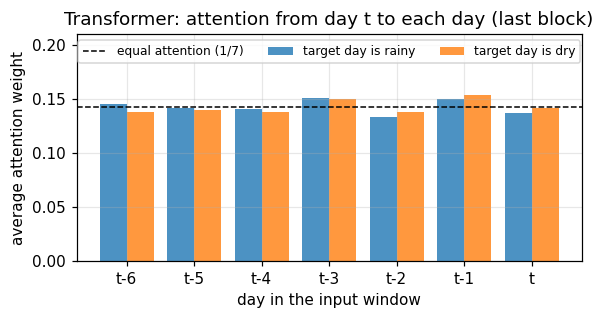

attention from day t: {'t-6': np.float32(0.14), 't-5': np.float32(0.14), 't-4': np.float32(0.139), 't-3': np.float32(0.15), 't-2': np.float32(0.137), 't-1': np.float32(0.153), 't': np.float32(0.141)}


In [18]:
@torch.no_grad()
def attention_from_today(model, tensors, batch=8192):
    model.eval(); out = []
    for s_ in range(0, len(tensors[0]), batch):
        model(*[t[s_:s_ + batch] for t in tensors])
        out.append(model.blocks[-1].last_weights[:, -1, :].numpy())   # row of day t
    return np.concatenate(out)

att = attention_from_today(trf_model, G["test"])
att_all, att_rain, att_dry = att.mean(0), att[y[te] == 1].mean(0), att[y[te] == 0].mean(0)
RESULTS["attention_from_day_t"] = {"all": att_all.round(4).tolist(), "rain": att_rain.round(4).tolist(), "dry": att_dry.round(4).tolist()}
labels_days = ["t-6", "t-5", "t-4", "t-3", "t-2", "t-1", "t"]
fig, ax = plt.subplots(figsize=(5.6, 3.0))
xx = np.arange(7)
ax.bar(xx - 0.2, att_rain, 0.4, label="target day is rainy", color="tab:blue", alpha=0.8)
ax.bar(xx + 0.2, att_dry, 0.4, label="target day is dry", color="tab:orange", alpha=0.8)
ax.axhline(1 / 7, color="k", ls="--", lw=1, label="equal attention (1/7)")
ax.set_xticks(xx); ax.set_xticklabels(labels_days); ax.set_ylabel("average attention weight"); ax.set_ylim(0, 0.21)
ax.set_xlabel("day in the input window"); ax.legend(fontsize=8, ncol=3, loc="upper center")
ax.set_title("Transformer: attention from day t to each day (last block)")
plt.tight_layout(); plt.savefig("figures/fig10_attention.png"); plt.show()
print("attention from day t:", dict(zip(labels_days, att_all.round(3))))

The attention is almost flat: every day gets between about 0.13 and 0.15, close to the equal share 1/7 = 0.143, and the
pattern is nearly the same for rainy and dry target days. In other words, the Transformer mostly takes an average of the
week instead of picking out special days. This agrees with the GRU result: for a target two days ahead, the recent history
adds little information beyond today's readings.

Learning curves of the three neural networks (seed 42). The training loss is measured with dropout switched on,
so it can be above the validation loss.

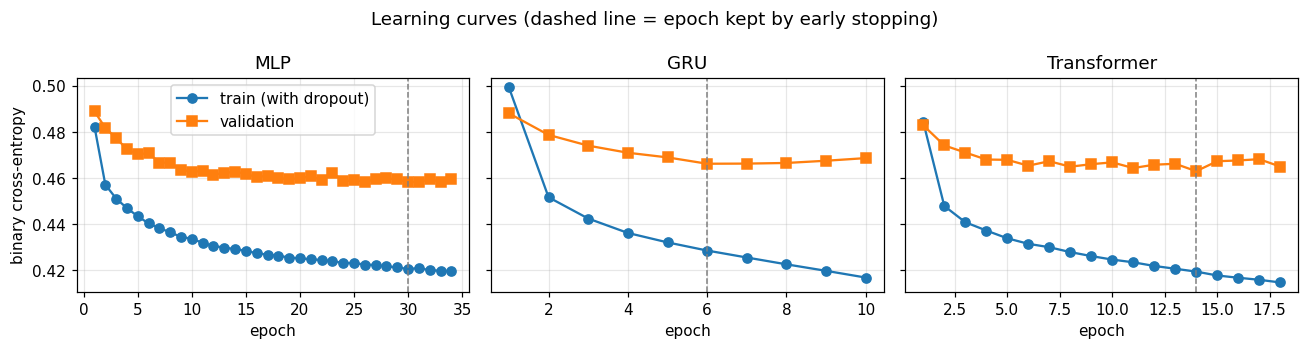

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, h, name in [(axes[0], mlp_hist, "MLP"), (axes[1], gru_hist, "GRU"), (axes[2], trf_hist, "Transformer")]:
    ax.plot(h.epoch, h.train_loss, "o-", label="train (with dropout)"); ax.plot(h.epoch, h.val_loss, "s-", label="validation")
    ax.axvline(h.epoch[h.val_loss.idxmin()], color="grey", ls="--", lw=1); ax.set_title(name); ax.set_xlabel("epoch")
axes[0].set_ylabel("binary cross-entropy"); axes[0].legend()
fig.suptitle("Learning curves (dashed line = epoch kept by early stopping)")
plt.tight_layout(); plt.savefig("figures/fig2_learning_curves.png"); plt.show()

## 9. From probability to decision: loss vs. task objective

**What the models optimise.** Cross-entropy only asks for good probabilities. It does not know about thresholds or costs.

**What the user needs.** A yes/no decision where a missed rain day (an outdoor event without cover, washing left outside,
a concrete pour that gets rained on) costs more than an unnecessary precaution. I set the cost ratio FN : FP = 3 : 1.
This is an assumption about the user, and Section 10.5 shows how the decision changes with other ratios.

**Why not train on the cost directly?** The cost counts errors after a hard threshold, so it is a step function of the
model output. Its gradient is zero almost everywhere, so gradient descent cannot use it (Module 3: a criterion that includes
a decision step can *evaluate* a model but cannot *train* it). So I train on cross-entropy and choose the threshold afterwards.

**Theory for the threshold.** If *p* is a correct probability, predicting "rain" costs $C_{FP}(1-p)$ on average and
predicting "no rain" costs $C_{FN}\,p$. Rain is the cheaper choice when $p > C_{FP}/(C_{FP}+C_{FN}) = 1/4 = 0.25$.
Below I compare this theoretical value with the threshold that gives the lowest cost on the validation years.

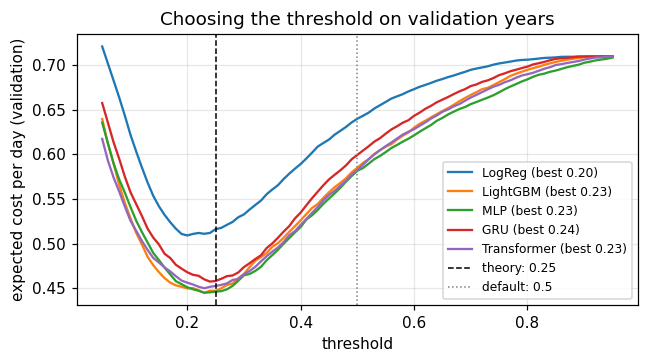

cost-optimal thresholds on validation: {'LogReg': 0.2, 'LightGBM': 0.23, 'MLP': 0.23, 'GRU': 0.24, 'Transformer': 0.23}


In [20]:
THR = {}
fig, ax = plt.subplots(figsize=(6, 3.4))
for name in ["LogReg", "LightGBM", "MLP", "GRU", "Transformer"]:
    THR[name], grid, costs = best_cost_threshold(y[va], P["val"][name])
    ax.plot(grid, costs, label=f"{name} (best {THR[name]:.2f})")
ax.axvline(0.25, color="k", ls="--", lw=1, label="theory: 0.25")
ax.axvline(0.5, color="grey", ls=":", lw=1, label="default: 0.5")
ax.set_xlabel("threshold"); ax.set_ylabel("expected cost per day (validation)"); ax.legend(fontsize=8)
ax.set_title("Choosing the threshold on validation years")
plt.tight_layout(); plt.savefig("figures/fig3_threshold_cost.png"); plt.show()
print("cost-optimal thresholds on validation:", THR)
RESULTS["thresholds"] = THR

The validation optimum is close to the theoretical 0.25 when the probabilities are well calibrated. The calibration
plot checks this: points on the diagonal mean that "p = 0.3" really rains about 30% of the time.

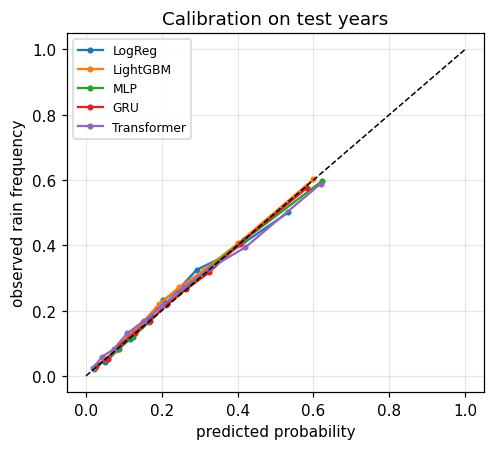

In [21]:
fig, ax = plt.subplots(figsize=(4.6, 4.2))
for name in ["LogReg", "LightGBM", "MLP", "GRU", "Transformer"]:
    fr, mp = calibration_curve(y[te], P["test"][name], n_bins=10, strategy="quantile")
    ax.plot(mp, fr, "o-", ms=3, label=name)
ax.plot([0, 1], [0, 1], "k--", lw=1); ax.set_xlabel("predicted probability"); ax.set_ylabel("observed rain frequency")
ax.set_title("Calibration on test years"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("figures/fig4_calibration.png"); plt.show()

### 9.1 Main results on the test years (2022 – Jan 2026)
Every model uses its own cost-optimal threshold from the validation years. The test set was not used for any choice.

In [22]:
rows = [evaluate(y[te], P["test"][m], THR[m], m) for m in ["LogReg", "LightGBM", "MLP", "GRU", "Transformer"]]
rows.append(evaluate(y[te], P["test"]["LightGBM"], 0.5, "LightGBM (default 0.5)"))
main = pd.concat([baselines[baselines.part == "test"].drop(columns="part"), pd.DataFrame(rows)], ignore_index=True)
cols = ["model", "log_loss", "brier", "roc_auc", "pr_auc", "threshold", "accuracy", "precision", "recall", "f1", "cost_per_day"]
main = main[cols]
main.to_csv("results/table_main_test.csv", index=False)
RESULTS["main_test"] = main.round(4).to_dict(orient="records")
main.round(3)

,model,log_loss,brier,roc_auc,pr_auc,threshold,accuracy,precision,recall,f1,cost_per_day
0,Always no rain,NaN,NaN,NaN,NaN,NaN,0.773,0.000,0.000,0.000,0.680
1,Persistence (rain today),NaN,NaN,NaN,NaN,NaN,0.706,0.349,0.345,0.347,0.591
2,Climatology (station x month),0.500,0.163,0.677,0.374,0.21,0.608,0.323,0.667,0.435,0.543
3,Humidity3pm > 60,NaN,NaN,NaN,NaN,NaN,0.663,0.343,0.531,0.417,0.549
4,LogReg,0.481,0.157,0.719,0.420,0.20,0.632,0.347,0.709,0.466,0.500
5,LightGBM,0.447,0.145,0.773,0.505,0.23,0.706,0.410,0.682,0.512,0.438
6,MLP,0.445,0.144,0.775,0.506,0.23,0.690,0.398,0.724,0.514,0.435
7,GRU,0.456,0.148,0.759,0.483,0.24,0.688,0.392,0.687,0.499,0.454
8,Transformer,0.454,0.147,0.764,0.489,0.23,0.692,0.398,0.696,0.506,0.445
9,LightGBM (default 0.5),0.447,0.145,0.773,0.505,0.50,0.795,0.635,0.223,0.330,0.557


**What the table shows (test years).**
- All four learned models have a lower cost per day than every simple rule. LightGBM and the MLP are the best
  (cost about 0.44 per day, against 0.59 for persistence and 0.55 for the humidity rule).
- LightGBM and the MLP are almost equal (PR-AUC about 0.51). The GRU and the Transformer, which see 7 days of history,
  are **not** better (PR-AUC about 0.48 and 0.49).
  Logistic Regression is clearly weaker (PR-AUC 0.42), so a linear boundary is not enough.
- With the default threshold 0.5, LightGBM has the highest accuracy of all models, but it catches only about 22% of the rain days.
  The cost-based threshold (0.23) catches about 68%. The threshold matters as much as the model.

Seed variation of the neural networks (3 seeds, test years, mean ± std):

In [23]:
def seed_summary(runs, name, thr):
    rs = pd.DataFrame([evaluate(y[te], r[2], thr, name) for r in runs])
    return {k: (float(rs[k].mean()), float(rs[k].std())) for k in ["log_loss", "pr_auc", "recall", "f1", "cost_per_day"]}
RESULTS["seed_var"] = {"MLP": seed_summary(mlp_runs, "MLP", THR["MLP"]), "GRU": seed_summary(gru_runs, "GRU", THR["GRU"]),
                      "Transformer": seed_summary(trf_runs, "Transformer", THR["Transformer"])}
for k, v in RESULTS["seed_var"].items():
    print(k, {m: f"{a:.4f} ± {b:.4f}" for m, (a, b) in v.items()})

MLP {'log_loss': '0.4461 ± 0.0009', 'pr_auc': '0.5065 ± 0.0020', 'recall': '0.7212 ± 0.0099', 'f1': '0.5133 ± 0.0016', 'cost_per_day': '0.4362 ± 0.0019'}
GRU {'log_loss': '0.4553 ± 0.0014', 'pr_auc': '0.4861 ± 0.0038', 'recall': '0.6834 ± 0.0055', 'f1': '0.5019 ± 0.0022', 'cost_per_day': '0.4508 ± 0.0027'}
Transformer {'log_loss': '0.4531 ± 0.0011', 'pr_auc': '0.4920 ± 0.0031', 'recall': '0.7097 ± 0.0140', 'f1': '0.5050 ± 0.0029', 'cost_per_day': '0.4468 ± 0.0037'}


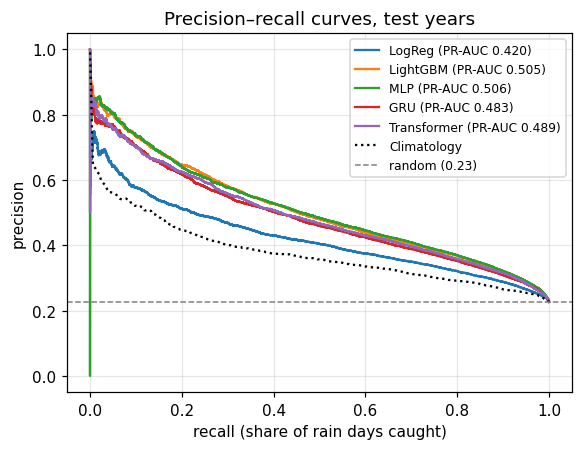

In [24]:
fig, ax = plt.subplots(figsize=(5.4, 4.2))
for name in ["LogReg", "LightGBM", "MLP", "GRU", "Transformer"]:
    pr, rc, _ = precision_recall_curve(y[te], P["test"][name])
    ax.plot(rc, pr, label=f"{name} (PR-AUC {average_precision_score(y[te], P['test'][name]):.3f})")
pc = precision_recall_curve(y[te], clim_p(te))
ax.plot(pc[1], pc[0], "k:", label="Climatology")
ax.axhline(y[te].mean(), color="grey", lw=1, ls="--", label=f"random ({y[te].mean():.2f})")
ax.set_xlabel("recall (share of rain days caught)"); ax.set_ylabel("precision"); ax.legend(fontsize=8)
ax.set_title("Precision–recall curves, test years")
plt.tight_layout(); plt.savefig("figures/fig5_pr_curves.png"); plt.show()

### 9.2 How big is the timing leak? The same pipeline on the "standard" Kaggle task
I repeat the LightGBM pipeline with (a) the standard label `RainTomorrow` and all columns of day *t*, and
(b) the same plus `RISK_MM`. Everything else (years, parameters, early stopping) is unchanged.

In [25]:
def run_lgb_task(frame, X, ycol):
    ii = {s: np.where(frame.split.values == s)[0] for s in ["train", "val", "test"]}
    yy = frame[ycol].values.astype(int)
    pp = Prep().fit(X.iloc[ii["train"]], frame.Location.iloc[ii["train"]])
    m = lgb.LGBMClassifier(**LGB_PARAMS)
    m.fit(lgb_frame(X.iloc[ii["train"]], frame.iloc[ii["train"]], pp), yy[ii["train"]],
          eval_set=[(lgb_frame(X.iloc[ii["val"]], frame.iloc[ii["val"]], pp), yy[ii["val"]])],
          callbacks=[lgb.early_stopping(100, verbose=False)])
    pv = m.predict_proba(lgb_frame(X.iloc[ii["val"]], frame.iloc[ii["val"]], pp))[:, 1]
    pt = m.predict_proba(lgb_frame(X.iloc[ii["test"]], frame.iloc[ii["test"]], pp))[:, 1]
    thr, _, _ = best_cost_threshold(yy[ii["val"]], pv)
    return evaluate(yy[ii["test"]], pt, thr)

Xs = feature_frame(data_std, "standard")
std_res = run_lgb_task(data_std, Xs, "y_standard")
Xs_leak = Xs.copy(); Xs_leak["RISK_MM"] = data_std.rain_t1.values
leak_res = run_lgb_task(data_std, Xs_leak, "y_standard")
honest_res = evaluate(y[te], P["test"]["LightGBM"], THR["LightGBM"])
gap = pd.DataFrame([{**honest_res, "task": "This project (9am t+1 → 9am t+2, time-safe inputs)"},
                    {**std_res, "task": "Standard Kaggle task (RainTomorrow, all columns of day t)"},
                    {**leak_res, "task": "Standard task + RISK_MM"}])[["task", "pr_auc", "roc_auc", "recall", "precision", "f1", "accuracy"]]
RESULTS["task_gap"] = gap.round(4).to_dict(orient="records")
gap.round(3)

,task,pr_auc,roc_auc,recall,precision,f1,accuracy
0,"This project (9am t+1 → 9am t+2, time-safe inp...",0.505,0.773,0.682,0.410,0.512,0.706
1,"Standard Kaggle task (RainTomorrow, all column...",0.773,0.904,0.778,0.607,0.682,0.836
2,Standard task + RISK_MM,1.000,1.000,1.000,1.000,1.000,1.000


**The timing leak is large.** With exactly the same pipeline, the standard Kaggle task reaches PR-AUC about 0.77, while
the time-safe task reaches about 0.51. The difference comes from inputs that are measured inside the target window
(3 pm readings, MaxTemp, Sunshine, WindGust) and from predicting a window that has already started.
Adding `RISK_MM` gives a perfect score, which is the clearest sign of a leak: a perfect score on real weather is not believable.
Many public results for this dataset are therefore measured on an easier question than the one they describe.

## 10. Reliability

### 10.1 Random split vs. time split
A random split puts neighbouring days (almost the same weather) into both train and test. I measure how much this
changes the score for the same LightGBM settings: 80/20 random split of 2008–2021 vs. the time split.

In [26]:
rng = np.random.RandomState(SEED)
pool = np.concatenate([tr, va]); rng.shuffle(pool)
cut = int(0.8 * len(pool)); rtr, rte = pool[:cut], pool[cut:]
m_rand = lgb.LGBMClassifier(**{**LGB_PARAMS, "n_estimators": BEST_ITER})
m_rand.fit(lgb_frame(Xh.iloc[rtr], data.iloc[rtr]), y[rtr])
p_rand = m_rand.predict_proba(lgb_frame(Xh.iloc[rte], data.iloc[rte]))[:, 1]
RESULTS["random_vs_time"] = {"random_split_pr_auc": float(average_precision_score(y[rte], p_rand)),
                             "time_split_pr_auc": float(average_precision_score(y[te], P["test"]["LightGBM"]))}
print(RESULTS["random_vs_time"])

{'random_split_pr_auc': 0.5162214151531282, 'time_split_pr_auc': 0.5052639940031521}


A random split estimates PR-AUC about 0.52, while the model really achieves about 0.51 on the future years.
Here the optimism is small (about 2%), because the target is two days ahead and neighbouring rows are only weakly
related. Still, the random split gives a number that the model cannot deliver in use, so I report the time-split result.

### 10.2 Year-by-year evaluation (rolling origin)
One test period gives one number. To see the spread, I train on all years before year *Y* and test on year *Y*,
for *Y* = 2020 … 2025 (six folds). The threshold is the one chosen in Section 9.

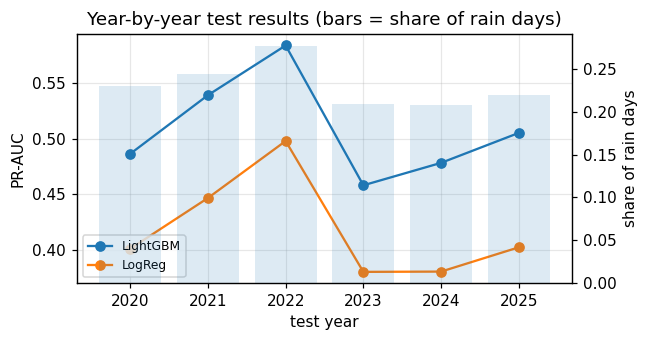

pr_auc        recall            f1        cost_per_day       
           mean    std   mean    std   mean    std         mean    std
model                                                                 
LightGBM  0.508  0.046  0.700  0.027  0.516  0.032        0.439  0.013
LogReg    0.418  0.046  0.723  0.015  0.469  0.030        0.504  0.013

In [27]:
roll = []
years = data.Date.dt.year.values
for Y in range(2020, 2026):
    a, b = np.where(years < Y)[0], np.where(years == Y)[0]
    pp = Prep().fit(Xh.iloc[a], data.Location.iloc[a])
    m1 = LogisticRegression(C=1.0, max_iter=3000).fit(lr_inputs(a, pp=pp), y[a])
    p1 = m1.predict_proba(lr_inputs(b, pp=pp))[:, 1]
    m2 = lgb.LGBMClassifier(**{**LGB_PARAMS, "n_estimators": BEST_ITER}).fit(lgb_frame(Xh.iloc[a], data.iloc[a], pp), y[a])
    p2 = m2.predict_proba(lgb_frame(Xh.iloc[b], data.iloc[b], pp))[:, 1]
    for name, p in [("LogReg", p1), ("LightGBM", p2)]:
        roll.append({**evaluate(y[b], p, THR[name], name), "year": Y, "rain_share": y[b].mean()})
roll = pd.DataFrame(roll)
summary_roll = roll.groupby("model")[["pr_auc", "recall", "f1", "cost_per_day"]].agg(["mean", "std"]).round(3)
RESULTS["rolling"] = {"per_year": roll[["model", "year", "pr_auc", "recall", "f1", "cost_per_day", "rain_share"]].round(4).to_dict(orient="records"),
                      "summary": {m: {c: [float(summary_roll.loc[m, (c, "mean")]), float(summary_roll.loc[m, (c, "std")])]
                                      for c in ["pr_auc", "recall", "f1", "cost_per_day"]} for m in summary_roll.index}}
fig, ax = plt.subplots(figsize=(6, 3.2))
for name, g in roll.groupby("model"):
    ax.plot(g.year, g.pr_auc, "o-", label=name)
ax2 = ax.twinx(); ax2.bar(roll.year.unique(), roll.groupby("year").rain_share.first(), alpha=0.15, color="tab:blue"); ax2.set_ylabel("share of rain days"); ax2.grid(False)
ax.set_xlabel("test year"); ax.set_ylabel("PR-AUC"); ax.legend(loc="lower left", fontsize=8)
ax.set_title("Year-by-year test results (bars = share of rain days)")
plt.tight_layout(); plt.savefig("figures/fig6_rolling_years.png"); plt.show()
summary_roll

Across six test years LightGBM has PR-AUC 0.51 ± 0.05 and Logistic Regression 0.42 ± 0.05. LightGBM wins in **every**
year, so the ranking does not depend on one lucky period. The score moves with the weather of the year: 2022 was very wet
(28% rain days, a La Niña year) and was the easiest year; dry years such as 2023–2024 are harder.

### 10.3 Stations the model has never seen
Could the model serve a **new** weather station? I use GroupKFold with 5 folds over stations: the model is trained on the
training years of about 39 stations and tested on the test years of the other ~10. The station feature is removed
(an unknown station has no embedding or category). I compare with the same model tested on known stations.

In [28]:
gkf = GroupKFold(n_splits=5)
locs_arr = data.Location.values
unseen = []
for k, (a_loc, b_loc) in enumerate(gkf.split(data, groups=locs_arr)):
    held = set(locs_arr[b_loc])
    a = np.array([i for i in tr if locs_arr[i] not in held]); b = np.array([i for i in te if locs_arr[i] in held])
    b_seen = np.array([i for i in te if locs_arr[i] not in held])
    m = lgb.LGBMClassifier(**{**LGB_PARAMS, "n_estimators": BEST_ITER}).fit(Xh.iloc[a], y[a])
    unseen.append({"fold": k, "unseen_pr_auc": average_precision_score(y[b], m.predict_proba(Xh.iloc[b])[:, 1]),
                   "seen_pr_auc": average_precision_score(y[b_seen], m.predict_proba(Xh.iloc[b_seen])[:, 1]),
                   "unseen_recall": evaluate(y[b], m.predict_proba(Xh.iloc[b])[:, 1], THR["LightGBM"])["recall"],
                   "n_unseen_stations": len(held)})
unseen = pd.DataFrame(unseen)
RESULTS["unseen_stations"] = {c: [float(unseen[c].mean()), float(unseen[c].std())] for c in ["unseen_pr_auc", "seen_pr_auc", "unseen_recall"]}
print(unseen.round(3).to_string(index=False))
print(RESULTS["unseen_stations"])

 fold  unseen_pr_auc  seen_pr_auc  unseen_recall  n_unseen_stations
    0          0.422        0.464          0.618                 10
    1          0.452        0.460          0.668                 10
    2          0.475        0.460          0.713                 10
    3          0.345        0.487          0.626                 10
    4          0.482        0.457          0.661                  9
{'unseen_pr_auc': [0.43525634706173444, 0.05573056553639444], 'seen_pr_auc': [0.46548123251081364, 0.012030854185119729], 'unseen_recall': [0.6573272876939, 0.0379721909946739]}


For stations the model has never seen, PR-AUC drops from about 0.47 to about 0.44, and the spread between folds is
much larger (± 0.06 instead of ± 0.01). The model can be used for a new station, but its quality is less predictable,
so a new station should be monitored for some months before its forecasts are trusted.

### 10.4 Where does the model fail?
**(a) By station.** Aggregate scores can hide stations where the model is weak.

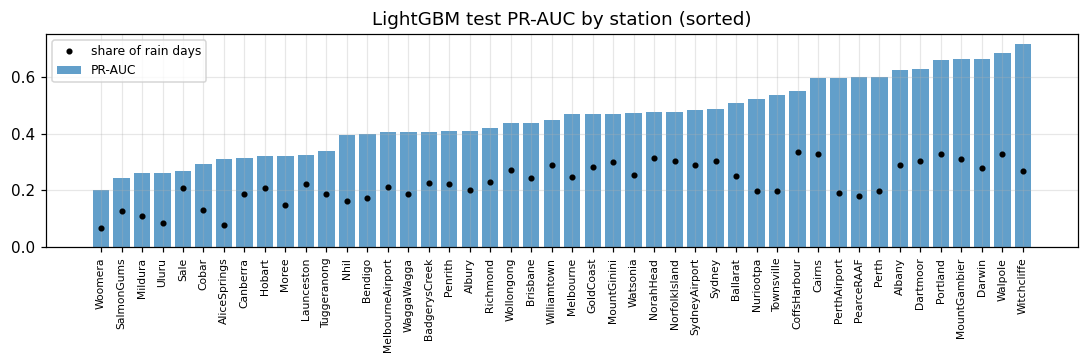

            rain_share  pr_auc  recall  precision    days
Location                                                 
Woomera          0.065   0.199   0.137      0.351  1458.0
SalmonGums       0.127   0.242   0.351      0.264  1478.0
Mildura          0.109   0.259   0.325      0.352  1447.0
Uluru            0.085   0.260   0.317      0.305  1478.0
Sale             0.207   0.269   0.128      0.271  1468.0
              rain_share  pr_auc  recall  precision    days
Location                                                   
Portland           0.329   0.660   0.836      0.490  1449.0
MountGambier       0.310   0.662   0.789      0.521  1456.0
Darwin             0.280   0.663   0.921      0.509  1489.0
Walpole            0.327   0.684   0.853      0.501  1454.0
Witchcliffe        0.268   0.715   0.912      0.509  1323.0


In [29]:
best_name = "LightGBM"
te_df = data.iloc[te].assign(p=P["test"][best_name], y=y[te])
per_loc = te_df.groupby("Location").apply(lambda g: pd.Series({
    "rain_share": g.y.mean(), "pr_auc": average_precision_score(g.y, g.p) if g.y.nunique() > 1 else np.nan,
    "recall": recall_score(g.y, g.p >= THR[best_name], zero_division=0),
    "precision": precision_score(g.y, g.p >= THR[best_name], zero_division=0), "days": len(g)})).sort_values("pr_auc")
RESULTS["per_location"] = per_loc.round(3).reset_index().to_dict(orient="records")
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.bar(per_loc.index, per_loc.pr_auc, color="tab:blue", alpha=0.7, label="PR-AUC")
ax.plot(per_loc.index, per_loc.rain_share, "k.", label="share of rain days")
ax.set_xticks(range(len(per_loc))); ax.set_xticklabels(per_loc.index, rotation=90, fontsize=7); ax.legend(fontsize=8)
ax.set_title("LightGBM test PR-AUC by station (sorted)")
plt.tight_layout(); plt.savefig("figures/fig7_per_station.png"); plt.show()
print(per_loc.head(5).round(3)); print(per_loc.tail(5).round(3))

The weakest stations are dry inland places (Woomera, Uluru, Mildura, Salmon Gums) where rain is rare and often comes from
isolated storms. The strongest are the wet coastal stations in south-west Western Australia and western Victoria
(Witchcliffe, Walpole, Portland, Mount Gambier) and Darwin, where rain comes with large, regular weather systems.
Sale (Victoria) is an outlier: normal rain frequency but low recall, so it would need its own check.

**(b) By the amount of rain.** The label treats 1.2 mm and 40 mm the same ("Yes"). Cross-entropy therefore gives
equal weight to a drizzle day and a storm day, but for most users heavy rain matters much more. The actual rainfall of the
target day (`rain_t2`) is used here **only to analyse errors**, never as an input.

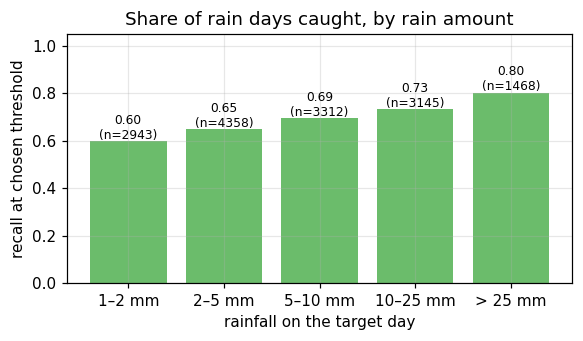

,days,recall,mean_p
amount,,,
1–2 mm,2943.0,0.600,0.307
2–5 mm,4358.0,0.650,0.333
5–10 mm,3312.0,0.695,0.360
10–25 mm,3145.0,0.734,0.382
> 25 mm,1468.0,0.803,0.409


In [30]:
bins = [1, 2, 5, 10, 25, np.inf]; labels = ["1–2 mm", "2–5 mm", "5–10 mm", "10–25 mm", "> 25 mm"]
rain_days = te_df[te_df.y == 1].copy()
rain_days["amount"] = pd.cut(rain_days.rain_t2, bins=bins, labels=labels, right=True)
by_amount = rain_days.groupby("amount").apply(lambda g: pd.Series({"days": len(g), "recall": (g.p >= THR[best_name]).mean(),
                                                                  "mean_p": g.p.mean()}))
RESULTS["recall_by_amount"] = by_amount.round(3).reset_index().astype({"amount": str}).to_dict(orient="records")
fig, ax = plt.subplots(figsize=(5.4, 3.2))
ax.bar(by_amount.index.astype(str), by_amount.recall, color="tab:green", alpha=0.7)
for i, (r, n) in enumerate(zip(by_amount.recall, by_amount.days)):
    ax.text(i, r + 0.01, f"{r:.2f}\n(n={int(n)})", ha="center", fontsize=8)
ax.set_ylim(0, 1.05); ax.set_ylabel("recall at chosen threshold"); ax.set_xlabel("rainfall on the target day")
ax.set_title("Share of rain days caught, by rain amount")
plt.tight_layout(); plt.savefig("figures/fig8_recall_by_amount.png"); plt.show()
by_amount.round(3)

Recall grows with the amount of rain: about 60% of the 1–2 mm days are caught, but about 80% of the days with more than 25 mm.
This is good news for users, but it also shows a gap between the loss and the real objective: cross-entropy treats a
1.2 mm day and a 40 mm day as the same "Yes", while a user cares much more about the 40 mm day.

**(c) Confusion matrix** of LightGBM at its chosen threshold (test years).

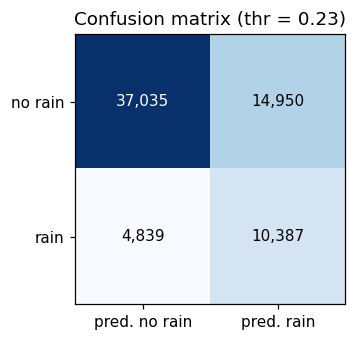

In [31]:
cm = confusion_matrix(y[te], (P["test"][best_name] >= THR[best_name]).astype(int))
RESULTS["confusion_lgb"] = cm.tolist()
fig, ax = plt.subplots(figsize=(3.6, 3.2))
ax.imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, f"{v:,}", ha="center", va="center", color="white" if v > cm.max() / 2 else "black")
ax.set_xticks([0, 1]); ax.set_xticklabels(["pred. no rain", "pred. rain"]); ax.set_yticks([0, 1]); ax.set_yticklabels(["no rain", "rain"])
ax.set_title(f"Confusion matrix (thr = {THR[best_name]:.2f})"); ax.grid(False)
plt.tight_layout(); plt.savefig("figures/fig9_confusion.png"); plt.show()

### 10.5 Sensitivity to my own design choices
I change one choice at a time (LightGBM, validation → test) and check whether the conclusions stay the same.
1. **Missing flags removed** – does keeping "missingness" help?
2. **Class weights** (`scale_pos_weight` = 3) instead of moving the threshold – two different answers to the cost problem.
3. **Cost ratio** 2 : 1 and 5 : 1 instead of 3 : 1 – how the threshold and the recall move.

In [32]:
sens = []
flag_cols = ["miss_sunshine", "miss_evap", "miss_cloud9", "miss_cloud3"]
Xnf = Xh.drop(columns=flag_cols)
ppn = Prep().fit(Xnf.iloc[tr], data.Location.iloc[tr])
m = lgb.LGBMClassifier(**LGB_PARAMS).fit(lgb_frame(Xnf.iloc[tr], data.iloc[tr], ppn), y[tr],
        eval_set=[(lgb_frame(Xnf.iloc[va], data.iloc[va], ppn), y[va])], callbacks=[lgb.early_stopping(100, verbose=False)])
pv, pt = [m.predict_proba(lgb_frame(Xnf.iloc[ii], data.iloc[ii], ppn))[:, 1] for ii in (va, te)]
sens.append({**evaluate(y[te], pt, best_cost_threshold(y[va], pv)[0]), "setting": "no missing flags"})

# Same number of trees as the main model. (With early stopping on the unweighted validation log-loss, the weighted
# model stopped after very few trees, because the weights push the probabilities away from the true frequencies.)
m = lgb.LGBMClassifier(**{**LGB_PARAMS, "n_estimators": BEST_ITER, "scale_pos_weight": 3.0}).fit(lgb_frame(Xh.iloc[tr], data.iloc[tr]), y[tr])
pt_w = m.predict_proba(lgb_frame(Xh.iloc[te], data.iloc[te]))[:, 1]
sens.append({**evaluate(y[te], pt_w, 0.5), "setting": "class weight 3, threshold 0.5"})
RESULTS["weighted_mean_p"] = {"weighted": float(pt_w.mean()), "unweighted": float(P["test"]["LightGBM"].mean()), "true_rate": float(y[te].mean())}
sens.append({**evaluate(y[te], P["test"]["LightGBM"], THR["LightGBM"]), "setting": "baseline design (flags, no weight, thr from val)"})

for cfn in [2.0, 5.0]:
    C_FN_saved = C_FN; C_FN = cfn
    t_c, _, _ = best_cost_threshold(y[va], P["val"]["LightGBM"])
    sens.append({**evaluate(y[te], P["test"]["LightGBM"], t_c), "setting": f"cost ratio {int(cfn)}:1 (theory thr {1/(1+cfn):.2f})"})
    C_FN = C_FN_saved
sens = pd.DataFrame(sens)[["setting", "log_loss", "brier", "pr_auc", "threshold", "precision", "recall", "f1"]]
RESULTS["sensitivity"] = sens.round(4).to_dict(orient="records")
sens.round(3)

,setting,log_loss,brier,pr_auc,threshold,precision,recall,f1
0,no missing flags,0.447,0.145,0.507,0.22,0.403,0.704,0.513
1,"class weight 3, threshold 0.5",0.519,0.175,0.506,0.50,0.431,0.628,0.511
2,"baseline design (flags, no weight, thr from val)",0.447,0.145,0.505,0.23,0.410,0.682,0.512
3,cost ratio 2:1 (theory thr 0.33),0.447,0.145,0.505,0.28,0.449,0.581,0.506
4,cost ratio 5:1 (theory thr 0.17),0.447,0.145,0.505,0.14,0.339,0.864,0.487


- Removing the missing flags does not change the result (PR-AUC 0.507 vs 0.505). LightGBM already handles missing values in its own way,
  so the flags are not needed for this model, but they are harmless.
- Class weights and threshold moving are two ways to express the same cost. Weight 3 pushes all probabilities up, so the
  probabilities are no longer calibrated (the log-loss becomes worse). Moving the threshold keeps calibrated probabilities,
  which a user can also read directly ("30% chance of rain"). I therefore keep the threshold approach.
- The cost ratio controls the trade-off directly: a ratio of 5:1 catches about 86% of rain days with more false alarms,
  a ratio of 2:1 catches about 58% with fewer. The chosen thresholds are close to the theory value 1/(1+ratio).

## 11. Deployment test: real 2026 data from BOM

The models were trained on 2008–2019. Now I download the newest BOM files (January–September 2026) for five capital
cities, build exactly the same inputs, and predict every day from 1 February to 31 August 2026.
None of these days existed when the training data was prepared. I also retrain LightGBM on all data up to January 2026
to see whether retraining helps.

I first checked that each BOM file matches the rattle station: for January 2026 every numeric value was identical
(the check is repeated below). One real difference appears: the Melbourne (Olympic Park) BOM file has no cloud readings
in 2026, so the model must rely on the missing flag there.

In [33]:
BOM_CODES = {"Sydney": "IDCJDW2124", "Melbourne": "IDCJDW3033", "Brisbane": "IDCJDW4019",
             "Perth": "IDCJDW6111", "Canberra": "IDCJDW2801"}
BOM_COLS = ["Date", "MinTemp", "MaxTemp", "Rainfall", "Evaporation", "Sunshine", "WindGustDir", "WindGustSpeed", "WindGustTime",
            "Temp9am", "Humidity9am", "Cloud9am", "WindDir9am", "WindSpeed9am", "Pressure9am",
            "Temp3pm", "Humidity3pm", "Cloud3pm", "WindDir3pm", "WindSpeed3pm", "Pressure3pm"]

def read_bom(path, location):
    lines = open(path, encoding="latin1").read().splitlines()
    rows = [l[1:] for l in lines if l.startswith(",20")]           # data rows start with ",YYYY-"
    df = pd.read_csv(io.StringIO("\n".join(rows)), header=None, names=BOM_COLS)
    df["Date"] = pd.to_datetime(df["Date"])
    for c in ["WindSpeed9am", "WindSpeed3pm"]:
        df[c] = pd.to_numeric(df[c].replace("Calm", 0), errors="coerce")   # BOM writes 'Calm' for 0 km/h
    for c in ["MinTemp", "MaxTemp", "Rainfall", "Evaporation", "Sunshine", "WindGustSpeed", "Temp9am", "Humidity9am",
              "Cloud9am", "Pressure9am", "Temp3pm", "Humidity3pm", "Cloud3pm", "Pressure3pm"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["Location"] = location
    return df.drop(columns="WindGustTime")

bom = []
for loc, code in BOM_CODES.items():
    for month in ["202601", "202602", "202603", "202604", "202605", "202606", "202607", "202608", "202609"]:
        path = f"data/bom_{code}_{month}.csv"
        download(f"https://www.bom.gov.au/climate/dwo/{month}/text/{code}.{month}.csv", path, SNAPSHOT_BASE + f"bom_{code}_{month}.csv")
        bom.append(read_bom(path, loc))
bom = pd.concat(bom, ignore_index=True)

# check: BOM January 2026 vs rattle January 2026
cmp = bom.merge(raw, on=["Location", "Date"], suffixes=("_bom", "_rattle"))
match = {c: float(np.isclose(cmp[c + "_bom"], cmp[c + "_rattle"])[cmp[c + "_bom"].notna() & cmp[c + "_rattle"].notna()].mean())
         for c in ["MinTemp", "Rainfall", "Humidity3pm", "Pressure3pm", "Temp9am"]}
print("January 2026 agreement BOM vs rattle:", match)

# previous days are needed for the lag features and the GRU window: use rattle up to 30 Jan, then BOM from 31 Jan
hist = raw[raw.Location.isin(BOM_CODES) & (raw.Date >= "2025-12-01")].drop(columns=["RainToday", "RainTomorrow", "RISK_MM"])
bom_new = bom[bom.Date > CUTOFF]
dep = add_features(complete_calendar(pd.concat([hist, bom_new], ignore_index=True)))
dep = dep[~dep.row_missing].reset_index(drop=True)
dep_mask = ((dep.Date >= "2026-02-01") & (dep.Date <= "2026-08-31") & dep.y_honest.notna()).values
D = dep[dep_mask].reset_index(drop=True)
yd = D.y_honest.values.astype(int)
Xd_all = feature_frame(dep, "honest"); Xd = Xd_all[dep_mask].reset_index(drop=True)
print("deployment days:", len(D), "| rain share:", round(yd.mean(), 3))

January 2026 agreement BOM vs rattle: {'MinTemp': 1.0, 'Rainfall': 1.0, 'Humidity3pm': 1.0, 'Pressure3pm': 1.0, 'Temp9am': 1.0}
deployment days: 1052 | rain share: 0.25


In [34]:
PD = {}
PD["LogReg"] = lr.predict_proba(np.hstack([prep.scaled(Xd), prep.onehot(D.Location)]))[:, 1]
PD["LightGBM"] = gbm.predict_proba(lgb_frame(Xd, D))[:, 1]
PD["MLP"] = predict_torch(mlp_model, [torch.tensor(prep.scaled(Xd)), torch.tensor(prep.loc_ids(D.Location))])
SEQd, _ = build_sequences(dep, dep_mask, Xd_all)
PD["GRU"] = predict_torch(gru_model, [torch.tensor(SEQd), torch.tensor(prep.loc_ids(D.Location))])
PD["Transformer"] = predict_torch(trf_model, [torch.tensor(SEQd), torch.tensor(prep.loc_ids(D.Location))])

# retrain LightGBM on 2008 - Jan 2026 (same settings, same number of trees)
all_i = np.arange(len(data))
pp_all = Prep().fit(Xh, data.Location)
gbm_all = lgb.LGBMClassifier(**{**LGB_PARAMS, "n_estimators": BEST_ITER}).fit(lgb_frame(Xh, data, pp_all), y)
PD["LightGBM retrained to 2026"] = gbm_all.predict_proba(lgb_frame(Xd, D, pp_all))[:, 1]

dep_rows = [evaluate_rule(yd, np.zeros(len(yd)), "Always no rain"),
            evaluate_rule(yd, D.Rainfall.values > 1, "Persistence (rain today)"),
            evaluate_rule(yd, D.Humidity3pm.fillna(prep.median["Humidity3pm"]).values > hum_cut, f"Humidity3pm > {hum_cut}")]
for name, p in PD.items():
    dep_rows.append(evaluate(yd, p, THR.get(name, THR["LightGBM"]), name))
dep_tab = pd.DataFrame(dep_rows)[cols]
dep_tab.to_csv("results/table_deployment_2026.csv", index=False)
RESULTS["deployment_2026"] = dep_tab.round(4).to_dict(orient="records")
RESULTS["deployment_2026_days"] = int(len(D)); RESULTS["deployment_2026_rain_share"] = float(yd.mean())
dep_city = pd.DataFrame([{"city": c, "days": int((D.Location == c).sum()), "rain_share": yd[D.Location == c].mean(),
                          "pr_auc": average_precision_score(yd[D.Location == c], PD["LightGBM"][D.Location == c]),
                          "recall": recall_score(yd[D.Location == c], PD["LightGBM"][D.Location == c] >= THR["LightGBM"])}
                         for c in BOM_CODES])
RESULTS["deployment_2026_by_city"] = dep_city.round(3).to_dict(orient="records")
print(dep_city.round(3).to_string(index=False))
dep_tab.round(3)

     city  days  rain_share  pr_auc  recall
   Sydney   212       0.321   0.552   0.794
Melbourne   212       0.236   0.441   0.700
 Brisbane   207       0.285   0.556   0.780
    Perth   212       0.241   0.584   0.686
 Canberra   209       0.167   0.443   0.571


,model,log_loss,brier,roc_auc,pr_auc,threshold,accuracy,precision,recall,f1,cost_per_day
0,Always no rain,NaN,NaN,NaN,NaN,NaN,0.750,0.000,0.000,0.000,0.750
1,Persistence (rain today),NaN,NaN,NaN,NaN,NaN,0.670,0.340,0.338,0.339,0.661
2,Humidity3pm > 60,NaN,NaN,NaN,NaN,NaN,0.638,0.346,0.502,0.409,0.611
3,LogReg,0.533,0.176,0.671,0.398,0.20,0.608,0.350,0.662,0.458,0.561
4,LightGBM,0.476,0.156,0.771,0.521,0.23,0.702,0.441,0.722,0.548,0.437
5,MLP,0.472,0.153,0.777,0.527,0.23,0.705,0.447,0.749,0.560,0.420
6,GRU,0.475,0.155,0.770,0.526,0.24,0.710,0.449,0.703,0.548,0.438
7,Transformer,0.476,0.155,0.775,0.515,0.23,0.705,0.446,0.734,0.555,0.428
8,LightGBM retrained to 2026,0.468,0.153,0.781,0.533,0.23,0.699,0.440,0.749,0.554,0.427


**Deployment result.** On 1,052 new station-days from 2026 the models keep their test-year quality (LightGBM PR-AUC 0.52,
MLP 0.53, GRU 0.53, Transformer 0.52) and clearly beat persistence and the humidity rule in cost. The models were trained only up to 2019, so they
are more than six years old, and they still work. Retraining LightGBM up to January 2026 gives only a small gain
(PR-AUC 0.53), which suggests no strong drift yet. Canberra is the weakest city: it is the driest of the five
(17% rain days). Melbourne is second weakest; its 2026 BOM file has no cloud readings, so the model relies on the missing flags there.

## 12. Cost of training and prediction (feasibility)
Measured on the machine that ran this notebook. Prediction latency is the time for one station-day.

In [35]:
one = Xh.iloc[te[:1]]
def per_row_ms(fn, reps=200):
    t0 = time.time()
    for _ in range(reps): fn()
    return (time.time() - t0) / reps * 1000
lat = {"LogReg": per_row_ms(lambda: lr.predict_proba(lr_inputs(te[:1]))),
       "LightGBM": per_row_ms(lambda: gbm.predict_proba(lgb_frame(one, data.iloc[te[:1]]))),
       "MLP": per_row_ms(lambda: predict_torch(mlp_model, [t[:1] for t in T_te])),
       "GRU": per_row_ms(lambda: predict_torch(gru_model, [t[:1] for t in G["test"]])),
       "Transformer": per_row_ms(lambda: predict_torch(trf_model, [t[:1] for t in G["test"]]))}
RESULTS["times_s"] = {k: round(v, 2) for k, v in TIMES.items()}
RESULTS["latency_ms"] = {k: round(v, 2) for k, v in lat.items()}
print("training time (s):", RESULTS["times_s"]); print("latency per station-day (ms):", RESULTS["latency_ms"])

training time (s): {'LogReg_train_s': 0.32, 'LightGBM_train_s': 7.1, 'MLP_train_s_per_seed': 3.75, 'GRU_train_s_per_seed': 8.91, 'Transformer_train_s_per_seed': 47.76}
latency per station-day (ms): {'LogReg': 1.81, 'LightGBM': 0.7, 'MLP': 0.04, 'GRU': 0.08, 'Transformer': 0.14}


## 13. Summary
The key numbers are saved to `results/results.json` and used in the journal.

In [36]:
def to_py(o):
    if isinstance(o, dict): return {str(k): to_py(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)): return [to_py(v) for v in o]
    if isinstance(o, (np.floating,)): return float(o)
    if isinstance(o, (np.integer,)): return int(o)
    return o
json.dump(to_py(RESULTS), open("results/results.json", "w"), indent=1)
print(pd.DataFrame(RESULTS["main_test"])[["model", "pr_auc", "threshold", "recall", "precision", "f1", "cost_per_day"]].round(3).to_string(index=False))

                        model  pr_auc  threshold  recall  precision    f1  cost_per_day
               Always no rain     NaN        NaN   0.000      0.000 0.000         0.680
     Persistence (rain today)     NaN        NaN   0.345      0.349 0.347         0.591
Climatology (station x month)   0.374       0.21   0.667      0.323 0.435         0.543
             Humidity3pm > 60     NaN        NaN   0.531      0.343 0.417         0.549
                       LogReg   0.420       0.20   0.709      0.347 0.466         0.500
                     LightGBM   0.505       0.23   0.682      0.410 0.512         0.438
                          MLP   0.506       0.23   0.724      0.398 0.514         0.435
                          GRU   0.483       0.24   0.687      0.392 0.499         0.454
                  Transformer   0.489       0.23   0.696      0.398 0.506         0.445
       LightGBM (default 0.5)   0.505       0.50   0.223      0.635 0.330         0.557
